# Data Analysis Project: E-Commerce Public Dataset
- **Nama:** Lulus Dwiyan Mita
- **Email:** m200d4ky2102@bangkit.academy
- **ID Dicoding:** M200D4KY2102


## Defining Business Questions

- In each product category, which product category has the top 10 highest sales?
- "What payment methods are most commonly used by customers for shopping in each state?"

## Import All Used Packages/Libraries

Importing several libraries such as pandas.

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate
import seaborn as sns
import warnings

In [62]:
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

## Data Wrangling

### Gathering Data

At this stage, data collection is carried out using e-commerce transaction data in Brazil within a specific timeframe. Subsequently, the data is read using pandas for datasets such as customers_dataset, geolocation_dataset, order_items_dataset, order_payments_dataset, order_reviews_dataset, orders_dataset, products_dataset, and sellers_dataset. Afterward, the top 5 rows for each dataset are displayed using the head() function.

In [63]:
cust_df = pd.read_csv("data/customers_dataset.csv", delimiter=",")
cust_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [64]:
geo_df = pd.read_csv("data/geolocation_dataset.csv", delimiter=",")
geo_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [65]:
orderit_df = pd.read_csv("data/order_items_dataset.csv", delimiter=",")
orderit_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [66]:
orderpay_df = pd.read_csv("data/order_payments_dataset.csv", delimiter=",")
orderpay_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [67]:
orderrev_df = pd.read_csv("data/order_reviews_dataset.csv", delimiter=",")
orderrev_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [68]:
order_df = pd.read_csv("data/orders_dataset.csv", delimiter=",")
order_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [69]:
prod_df = pd.read_csv("data/products_dataset.csv", delimiter=",")
prod_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [70]:
sell_df = pd.read_csv("data/sellers_dataset.csv", delimiter=",")
sell_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


### Assessing Data

Assessing data is a process aimed at identifying issues within the data and ensuring its quality.

### Customers

In [71]:
cust_df.info()
print("Duplicate count: ", cust_df.duplicated().sum())
cust_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
Duplicate count:  0


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


Based on the analysis of customer data, no data type errors, missing values, or duplicate values were found. Therefore, there is no need for data cleaning.

In [72]:
geo_df.info()
print("Duplicate count: ", geo_df.duplicated().sum())
geo_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


Duplicate count:  261831


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


Based on the geolocation data analysis, no data type errors were found, there are no missing values, but there are many duplicate data indicating that the seller or buyer is located in the same geolocation.

### Order Items

In [73]:
orderit_df.info()
print("Duplicate count: ", orderit_df.duplicated().sum())
orderit_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


Duplicate count:  0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


Based on the analysis, errors were found in the data type of the shipping limit date, but there are no missing values or duplicate data.

### Order Payments

In [74]:
orderpay_df.info()
print("Duplicate count: ", orderpay_df.duplicated().sum())
orderpay_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
Duplicate count:  0


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


Based on the analysis of customer data, no data type errors, missing values, or duplicate values were found. Therefore, there is no need for data cleaning.

### Order Reviews

In [75]:
orderrev_df.info()
print("Duplicate count: ", orderrev_df.duplicated().sum())
orderrev_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


Duplicate count:  0


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


There are many missing values in the review_comment_title and review_comment_message features, indicating that sometimes customers only provide a rating without leaving a message. Additionally, within the data, it is observed that the review scores are in the range of 1-5.

In [76]:
orderrev_df.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

It is noted that there are 87,656 missing values in the review_comment_title and 58,247 missing values in the review_comment_message.

### Orders

In [77]:
order_df.info()
print("Duplicate count: ", order_df.duplicated().sum())
order_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


Duplicate count:  0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


Based on the analysis, there are no duplicate data, but there are data type errors in columns 3 to 7. The analysis also indicates a significant number of missing values in order_approved_at, order_delivered_carrier_date, and order_delivered_customer_date columns.

In [78]:
order_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

It is noted that there are 160 missing values in the order_approved_at,1783 missing values in the order_delivered_carrier_date and 2965 missing values in the order_delivered_customer_date.

### Products

In [79]:
prod_df.info()
print("Duplicate count: ", prod_df.duplicated().sum())
prod_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
Duplicate count:  0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


Based on the analysis, no duplicate data was found, but there are missing values in many features ranging from columns 1 to 8.

In [80]:
prod_df.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

It is evident that product_category_name, product_name_length, product_description_length, and product_photos_qty have 610 missing values each. For the other features, excluding product_id, there are 2 missing values.

### Sellers

In [81]:
sell_df.info()
print("Duplicate count: ", sell_df.duplicated().sum())
sell_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB
Duplicate count:  0


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


Based on the analysis of sellers data, no data type errors, missing values, or duplicate values were found. Therefore, there is no need for data cleaning.

### Cleaning Data

Cleaning data in data wrangling, also known as data cleaning or data cleansing is the process of identifying and correcting errors or inconsistencies in datasets to improve their quality and reliability.

### Order Items

In [82]:
orderit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [83]:
datetime_columns = ["shipping_limit_date"]
 
for column in datetime_columns:
  orderit_df[column] = pd.to_datetime(orderit_df[column])

converting the "shipping_limit_date" column in a DataFrame (presumably named orderit_df) from its original data type to the datetime data type

In [84]:
orderit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


The data type of shipping_limit_date has been successfully changed to datetime.

### Order Reviews

In [85]:
orderrev_df.info()
orderrev_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


Because the data types of review_creation_date and review_answer_timestamp are not appropriate, they need to be changed to the datetime data type first.

In [86]:
datetime_columns = ["review_creation_date","review_answer_timestamp"]
 
for column in datetime_columns:
  orderrev_df[column] = pd.to_datetime(orderrev_df[column])

In [87]:
orderrev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


The data type of review_creation_date and review_anwer_timestamp has been successfully changed to datetime.

In [88]:
columns = ['review_comment_title', 'review_comment_message']
orderrev_df = orderrev_df.drop(columns, axis=1)
orderrev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_creation_date     99224 non-null  datetime64[ns]
 4   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(2)
memory usage: 3.8+ MB


It appears that previously, there were many missing values in the title and message comment features. Therefore, one possible data cleaning option could be to drop the title and message comment features.

### Orders

In [89]:
order_df.info()
order_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [90]:
datetime_columns = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']

for column in datetime_columns:
  order_df[column] = pd.to_datetime(order_df[column])

order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


The data type has been changed appropriately using datetime.

In [91]:
order_df[order_df.order_approved_at.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaT,NaT,NaT,2018-10-17
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaT,NaT,NaT,2017-04-10
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaT,NaT,NaT,2018-09-13
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaT,NaT,NaT,2017-05-30
...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaT,NaT,NaT,2017-07-25
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaT,NaT,NaT,2017-10-16
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaT,NaT,NaT,2018-08-10
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01


In [92]:
order_df[order_df.order_delivered_carrier_date.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
266,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaT,NaT,2017-12-05
324,d3c8851a6651eeff2f73b0e011ac45d0,957f8e082185574de25992dc659ebbc0,processing,2016-10-05 22:44:13,2016-10-06 15:51:05,NaT,NaT,2016-12-09
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaT,NaT,2018-02-06
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15


In [93]:
order_df[order_df.order_delivered_customer_date.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT,2018-02-07
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaT,NaT,2018-02-06
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15


The missing values in the three features appear to occur in pairs.Next step is to perform sorting for each feature, followed by filling the missing values using forward fill.

In [94]:
order_df = order_df.sort_values('order_approved_at')
order_df['order_approved_at']=order_df['order_approved_at'].fillna(method='ffill')

order_df = order_df.sort_values('order_delivered_carrier_date')
order_df['order_delivered_carrier_date']=order_df['order_delivered_carrier_date'].fillna(method='ffill')

order_df = order_df.sort_values('order_delivered_customer_date')
order_df['order_delivered_customer_date']=order_df['order_delivered_customer_date'].fillna(method='ffill')

In [95]:
order_df.info()
order_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 99441 entries, 59102 to 99347
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99441 non-null  datetime64[ns]
 5   order_delivered_carrier_date   99441 non-null  datetime64[ns]
 6   order_delivered_customer_date  99441 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.8+ MB


order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

It appears that all missing values have been filled using the forward fill method.

### Products

In [96]:
prod_df.info()
prod_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [97]:
prod_df[prod_df.product_category_name.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


Next is to perform dropping for missing values in the 'category name' where the count is not too significant.

In [98]:
prod_df=prod_df.dropna()
prod_df.isna().sum()


product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

Thus, it can be seen that there are no missing values anymore.

## Exploratory Data Analysis

In [100]:
order1_df=pd.merge(
    left=order_df,
    right=orderit_df,
    how='inner',
    left_on="order_id",
    right_on="order_id"
)

order2_df=pd.merge(
    left=orderrev_df,
    right=orderpay_df,
    how='inner',
    left_on="order_id",
    right_on="order_id"
)

order_all_df=pd.merge(
    left=order1_df,
    right=order2_df,
    how='inner',
    left_on="order_id",
    right_on="order_id"
)

The stage referring to involves merging several datasets into one using an inner join. These datasets include orders, order items, order payments, and order reviews.

In [101]:
order_all_df.info()
order_all_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117329 entries, 0 to 117328
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       117329 non-null  object        
 1   customer_id                    117329 non-null  object        
 2   order_status                   117329 non-null  object        
 3   order_purchase_timestamp       117329 non-null  datetime64[ns]
 4   order_approved_at              117329 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117329 non-null  datetime64[ns]
 6   order_delivered_customer_date  117329 non-null  datetime64[ns]
 7   order_estimated_delivery_date  117329 non-null  datetime64[ns]
 8   order_item_id                  117329 non-null  int64         
 9   product_id                     117329 non-null  object        
 10  seller_id                      117329 non-null  object        
 11  

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,review_id,review_score,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value
0,36989eb07a0de2d3d3129eea35553875,aadd27185177fc7ac9b364898ac09343,delivered,2016-10-04 13:11:29,2016-10-04 13:46:31,2016-10-08 13:46:32,2016-10-11 13:46:32,2016-12-06,1,43bb8825dd6838251606e5e4130cfff4,...,23.90,26.82,7d58a5b4bc501c1ece8972fa04351be2,5,2016-10-20,2016-10-21 01:50:25,1,credit_card,10,101.44
1,36989eb07a0de2d3d3129eea35553875,aadd27185177fc7ac9b364898ac09343,delivered,2016-10-04 13:11:29,2016-10-04 13:46:31,2016-10-08 13:46:32,2016-10-11 13:46:32,2016-12-06,2,43bb8825dd6838251606e5e4130cfff4,...,23.90,26.82,7d58a5b4bc501c1ece8972fa04351be2,5,2016-10-20,2016-10-21 01:50:25,1,credit_card,10,101.44
2,7033745709b7cf1bac7d2533663592de,7f0ca17bb33b230b47459437cf0682c7,delivered,2016-10-04 14:13:22,2016-10-04 14:46:48,2016-10-08 14:46:49,2016-10-11 14:46:49,2016-11-30,1,35084deab9603bbb6035bb8638b1df89,...,93.90,17.61,a0ba97ce98f76cf57bb2c5530513be70,3,2016-10-25,2016-10-26 23:52:15,1,credit_card,4,111.51
3,d1eb8e4e276a4eea13a5c462c0765e60,9031f9dcde5860b34e6c65ac5c796d30,delivered,2016-10-04 19:30:28,2016-10-06 03:10:33,2016-10-10 03:10:34,2016-10-13 03:10:34,2016-12-06,1,c3b8f6be3507bb05fd83797f81f679bc,...,19.99,20.80,5c0e0341b2115336ec6b975f5c8abfe8,5,2016-10-20,2016-10-21 01:13:00,1,boleto,1,40.79
4,92b44b87f1f7670b8911c5f0e642435e,e561a3f61440b031d3be286a696d06eb,delivered,2016-10-05 11:08:46,2016-10-06 07:45:47,2016-10-10 07:45:48,2016-10-13 07:45:48,2016-11-25,1,f07ef9dd6e2d9a366ff30a25e210be70,...,149.99,11.66,e04c5b55d009fa34754fe9d38c76d181,5,2016-10-22,2016-10-24 19:24:58,1,boleto,1,161.65


### Question 1


- In each product category, which product category has top 10 the highest sales?

In [102]:
prod_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [103]:
categories = prod_df['product_category_name'].unique()
print("Unique Product Categories:", categories)
print("Sum of Unique Product Categories:", len(categories))

Unique Product Categories: ['perfumaria' 'artes' 'esporte_lazer' 'bebes' 'utilidades_domesticas'
 'instrumentos_musicais' 'cool_stuff' 'moveis_decoracao'
 'eletrodomesticos' 'brinquedos' 'cama_mesa_banho'
 'construcao_ferramentas_seguranca' 'informatica_acessorios'
 'beleza_saude' 'malas_acessorios' 'ferramentas_jardim'
 'moveis_escritorio' 'automotivo' 'eletronicos' 'fashion_calcados'
 'telefonia' 'papelaria' 'fashion_bolsas_e_acessorios' 'pcs'
 'casa_construcao' 'relogios_presentes'
 'construcao_ferramentas_construcao' 'pet_shop' 'eletroportateis'
 'agro_industria_e_comercio' 'moveis_sala' 'sinalizacao_e_seguranca'
 'climatizacao' 'consoles_games' 'livros_interesse_geral'
 'construcao_ferramentas_ferramentas' 'fashion_underwear_e_moda_praia'
 'fashion_roupa_masculina'
 'moveis_cozinha_area_de_servico_jantar_e_jardim'
 'industria_comercio_e_negocios' 'telefonia_fixa'
 'construcao_ferramentas_iluminacao' 'livros_tecnicos'
 'eletrodomesticos_2' 'artigos_de_festas' 'bebidas' 'market_plac

So it can be understood that there are 73 unique product categories in the e-commerce data.

In [104]:
category_sales = prod_df.groupby('product_category_name')['product_id'].nunique()
print("Total Sales for Each Product Category:")
print(category_sales)

Total Sales for Each Product Category:
product_category_name
agro_industria_e_comercio      74
alimentos                      82
alimentos_bebidas             104
artes                          55
artes_e_artesanato             19
                             ... 
sinalizacao_e_seguranca        93
tablets_impressao_imagem        9
telefonia                    1134
telefonia_fixa                116
utilidades_domesticas        2335
Name: product_id, Length: 73, dtype: int64


In the code, the purpose is to calculate the sales quantity for each product category.

In [105]:
top_10_categories = category_sales.nlargest(10)

print("Top 10 Product Categories by Sales:")
print(top_10_categories)

Top 10 Product Categories by Sales:
product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: product_id, dtype: int64


By using `nlargest`, we can identify the top 10 products with the highest sales.

### Question 2

- What payment methods are most commonly used by customers for shopping in each state?

In [106]:
order_all_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,review_id,review_score,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value
0,36989eb07a0de2d3d3129eea35553875,aadd27185177fc7ac9b364898ac09343,delivered,2016-10-04 13:11:29,2016-10-04 13:46:31,2016-10-08 13:46:32,2016-10-11 13:46:32,2016-12-06,1,43bb8825dd6838251606e5e4130cfff4,...,23.90,26.82,7d58a5b4bc501c1ece8972fa04351be2,5,2016-10-20,2016-10-21 01:50:25,1,credit_card,10,101.44
1,36989eb07a0de2d3d3129eea35553875,aadd27185177fc7ac9b364898ac09343,delivered,2016-10-04 13:11:29,2016-10-04 13:46:31,2016-10-08 13:46:32,2016-10-11 13:46:32,2016-12-06,2,43bb8825dd6838251606e5e4130cfff4,...,23.90,26.82,7d58a5b4bc501c1ece8972fa04351be2,5,2016-10-20,2016-10-21 01:50:25,1,credit_card,10,101.44
2,7033745709b7cf1bac7d2533663592de,7f0ca17bb33b230b47459437cf0682c7,delivered,2016-10-04 14:13:22,2016-10-04 14:46:48,2016-10-08 14:46:49,2016-10-11 14:46:49,2016-11-30,1,35084deab9603bbb6035bb8638b1df89,...,93.90,17.61,a0ba97ce98f76cf57bb2c5530513be70,3,2016-10-25,2016-10-26 23:52:15,1,credit_card,4,111.51
3,d1eb8e4e276a4eea13a5c462c0765e60,9031f9dcde5860b34e6c65ac5c796d30,delivered,2016-10-04 19:30:28,2016-10-06 03:10:33,2016-10-10 03:10:34,2016-10-13 03:10:34,2016-12-06,1,c3b8f6be3507bb05fd83797f81f679bc,...,19.99,20.80,5c0e0341b2115336ec6b975f5c8abfe8,5,2016-10-20,2016-10-21 01:13:00,1,boleto,1,40.79
4,92b44b87f1f7670b8911c5f0e642435e,e561a3f61440b031d3be286a696d06eb,delivered,2016-10-05 11:08:46,2016-10-06 07:45:47,2016-10-10 07:45:48,2016-10-13 07:45:48,2016-11-25,1,f07ef9dd6e2d9a366ff30a25e210be70,...,149.99,11.66,e04c5b55d009fa34754fe9d38c76d181,5,2016-10-22,2016-10-24 19:24:58,1,boleto,1,161.65


In [107]:
customer_cols = ['customer_id', 'customer_state']
order_all_cols = ['order_id', 'customer_id','payment_type']
merged_df = pd.merge(cust_df[customer_cols], order_all_df[order_all_cols], on='customer_id', how='inner')
merged_df.head()

,customer_id,customer_state,order_id,payment_type
0,06b8999e2fba1a1fbc88172c00ba8bc7,SP,00e7ee1b050b8499577073aeb2a297a1,credit_card
1,18955e83d337fd6b2def6b18a428ac77,SP,29150127e6685892b6eab3eec79f59c7,credit_card
2,4e7b3e00288586ebd08712fdd0374a03,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,credit_card
3,b2b6027bc5c5109e529d4dc6358b12c3,SP,951670f92359f4fe4a63112aa7306eba,credit_card
4,4f2d8ab171c80ec8364f7c12e35b23ad,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,credit_card


At this stage, we are merging the customer and order all datasets, but only selecting specific columns to obtain a new table that has been merged.

In [108]:
unique_states = merged_df['customer_state'].unique()
print("Unique States:", unique_states)
print("Total Unique States:", len(unique_states))

Unique States: ['SP' 'SC' 'MG' 'PR' 'RJ' 'RS' 'PA' 'GO' 'ES' 'BA' 'MA' 'MS' 'CE' 'DF'
 'RN' 'PE' 'MT' 'AM' 'AP' 'AL' 'RO' 'PB' 'TO' 'PI' 'AC' 'SE' 'RR']
Total Unique States: 27


In [109]:
unique_payment_type = merged_df['payment_type'].unique()
print("Payment Type:", unique_payment_type)
print("Total Unique Payment Type:", len(unique_payment_type))

Payment Type: ['credit_card' 'debit_card' 'boleto' 'voucher']
Total Unique Payment Type: 4


It can be observed that there are 27 unique states in this dataset, and we will now investigate the most frequently used payment types for each state.

In [110]:
state_payment_counts = merged_df.groupby(['customer_state', 'payment_type']).size().reset_index(name='count')
print("Payment Type Counts by State:")
print(state_payment_counts)

Payment Type Counts by State:
    customer_state payment_type  count
0               AC       boleto     16
1               AC  credit_card     72
2               AC   debit_card      2
3               AC      voucher      5
4               AL       boleto     73
..             ...          ...    ...
100             SP      voucher   2746
101             TO       boleto     81
102             TO  credit_card    226
103             TO   debit_card      4
104             TO      voucher     27

[105 rows x 3 columns]


In [111]:
state_payment_counts = merged_df.groupby(['customer_state', 'payment_type']).size().reset_index(name='count')
idx_max_payment_type = state_payment_counts.groupby('customer_state')['count'].idxmax()
most_used_payment_types = state_payment_counts.loc[idx_max_payment_type]

print("Most Used Payment Types by State:")
print(most_used_payment_types)

Most Used Payment Types by State:
    customer_state payment_type  count
1               AC  credit_card     72
5               AL  credit_card    368
9               AM  credit_card    135
13              AP  credit_card     56
16              BA  credit_card   2961
20              CE  credit_card   1214
24              DF  credit_card   1918
28              ES  credit_card   1714
32              GO  credit_card   1751
36              MA  credit_card    574
40              MG  credit_card  10152
44              MS  credit_card    605
48              MT  credit_card    768
52              PA  credit_card    797
56              PB  credit_card    472
60              PE  credit_card   1456
64              PI  credit_card    416
68              PR  credit_card   4317
72              RJ  credit_card  11536
76              RN  credit_card    430
80              RO  credit_card    203
84              RR  credit_card     38
86              RS  credit_card   4533
90              SC  credit_car

It can be known that the most widely used type of payment in each state is credit cards.

## Visualization & Explanatory Analysis

### For Question 1:

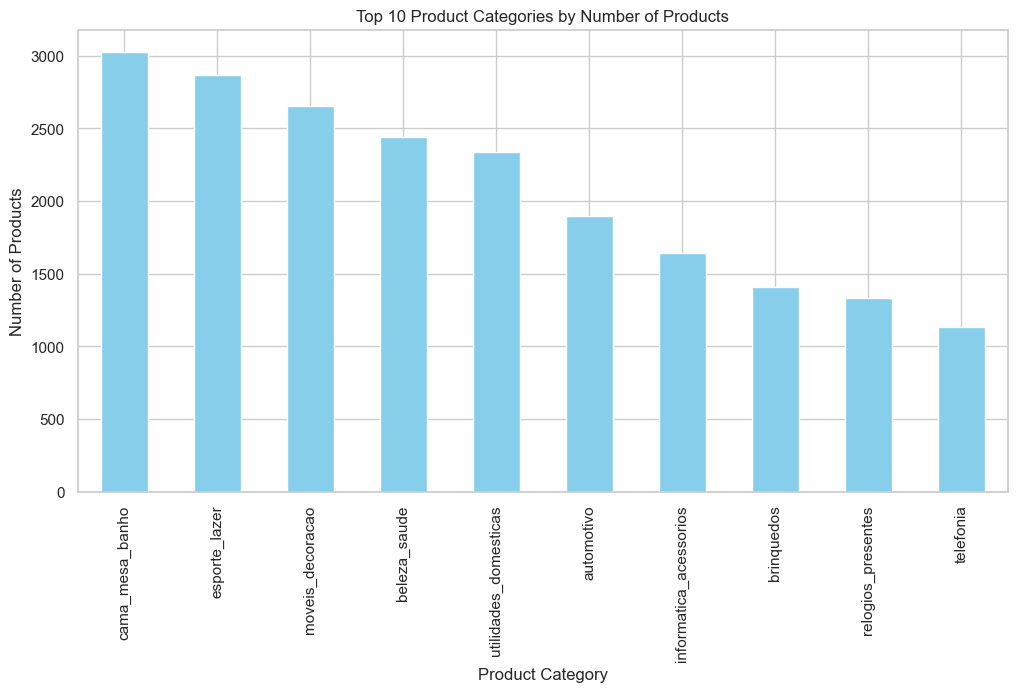

In [112]:
top_10_category_counts = prod_df['product_category_name'].value_counts().nlargest(10)

top_10_category_counts.plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title('Top 10 Product Categories by Number of Products')
plt.xlabel('Product Category')
plt.ylabel('Number of Products')
plt.show()


The visualizations explain the quantity of product sales for each category, from which it can be observed that "cama_mesa_banho" is the best-selling product category with sales exceeding 3000 products.

In [113]:
top_10_category_counts = prod_df['product_category_name'].value_counts().nlargest(10)
table_data = [(category, count) for category, count in zip(top_10_category_counts.index, top_10_category_counts)]
table_headers = ['Product Category', 'Number of Selling Products']
print(tabulate(table_data, headers=table_headers, tablefmt='pretty'))

+------------------------+----------------------------+
|    Product Category    | Number of Selling Products |
+------------------------+----------------------------+
|    cama_mesa_banho     |            3029            |
|     esporte_lazer      |            2867            |
|    moveis_decoracao    |            2657            |
|      beleza_saude      |            2444            |
| utilidades_domesticas  |            2335            |
|       automotivo       |            1900            |
| informatica_acessorios |            1639            |
|       brinquedos       |            1411            |
|   relogios_presentes   |            1329            |
|       telefonia        |            1134            |
+------------------------+----------------------------+


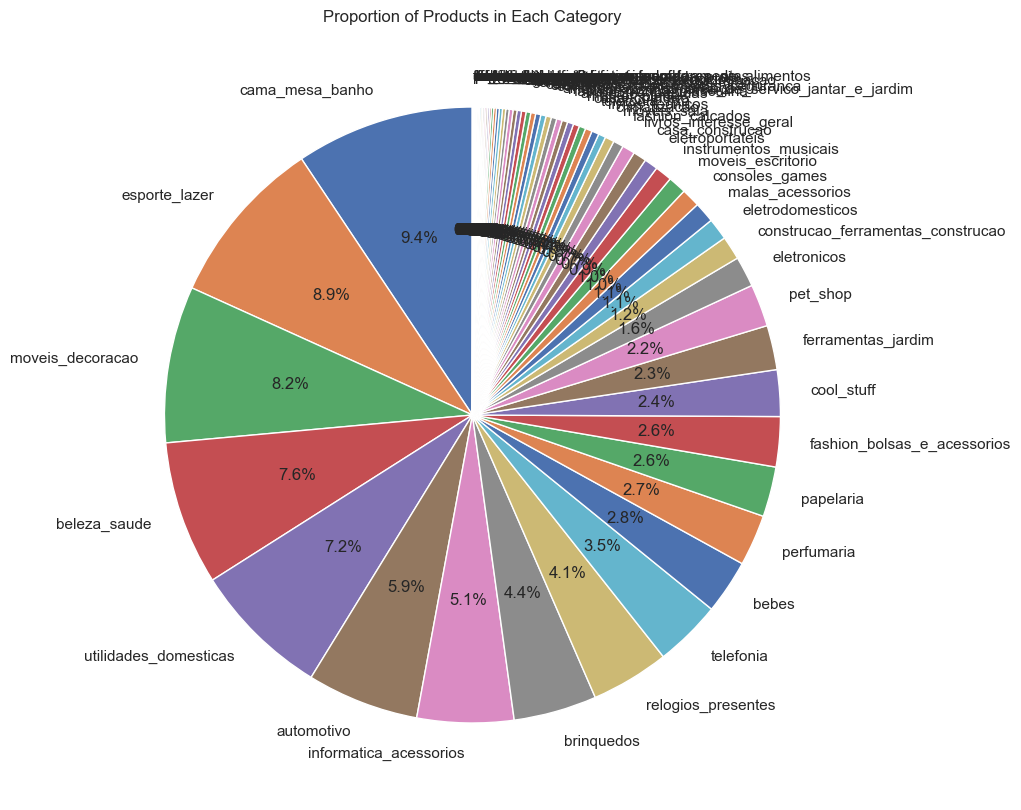

In [114]:
category_proportions = prod_df['product_category_name'].value_counts(normalize=True)
category_proportions.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(10, 10))
plt.title('Proportion of Products in Each Category')
plt.ylabel('')
plt.show()

From the pie chart, it can be observed that "cama mesa banho" represents a sales proportion of 9.4%, followed by "esporte lazer" with 8.9%.

### For Question 2

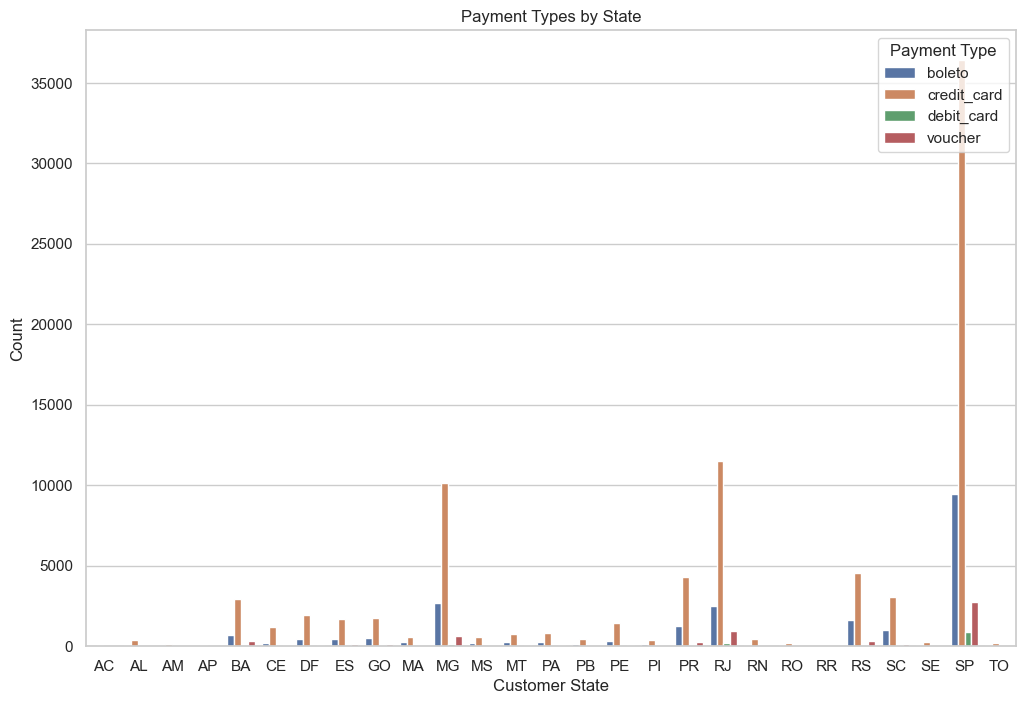

In [115]:

sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))
bar_plot = sns.barplot(x='customer_state', y='count', hue='payment_type', data=state_payment_counts)
plt.xlabel('Customer State')
plt.ylabel('Count')
plt.title('Payment Types by State')

plt.legend(title='Payment Type', loc='upper right')
plt.show()

In [116]:
import pandas as pd

table_data = state_payment_counts.pivot_table(values='count', index='customer_state', columns='payment_type', fill_value=0)

most_common_payment_type = state_payment_counts.loc[state_payment_counts.groupby('customer_state')['count'].idxmax()][['customer_state', 'payment_type']]
most_common_payment_type = most_common_payment_type.set_index('customer_state')['payment_type']
table_data['most_common_payment_type'] = most_common_payment_type

table_data.reset_index(inplace=True)

table_data.head(27)



payment_type,customer_state,boleto,credit_card,debit_card,voucher,most_common_payment_type
0,AC,16.0,72.0,2.0,5.0,credit_card
1,AL,73.0,368.0,5.0,13.0,credit_card
2,AM,26.0,135.0,2.0,7.0,credit_card
3,AP,24.0,56.0,0.0,3.0,credit_card
4,BA,700.0,2961.0,53.0,300.0,credit_card
5,CE,225.0,1214.0,20.0,86.0,credit_card
6,DF,451.0,1918.0,18.0,95.0,credit_card
7,ES,463.0,1714.0,27.0,115.0,credit_card
8,GO,511.0,1751.0,26.0,128.0,credit_card
9,MA,238.0,574.0,5.0,26.0,credit_card


## Conclusion

- The leading category is "cama_mesa_banho" with a remarkable 3029 products sold, constituting 9.4% of the total sales. Following closely is "esporte_lazer" with 2867 products sold, accounting for 8.9% of the overall sales. The third position is occupied by "moveis_decoracao" with 2657 products sold, representing 8.2% of the total sales. The remaining categories in the top 10 also contribute significantly to the overall sales, ranging from beleza saude products to telefonia. This analysis provides valuable insights into the key product categories driving sales.

- Based on the analysis results, it can be observed that the majority of the population or customers in all states in Brazil prefer to shop using credit card payments compared to other payment types. The highest number of users is found in the state of São Paulo.